### Модуль создания, обучения и тестирования модели для задачи Keyword Spotting.

In [3]:
import librosa
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from pathlib import Path
from tqdm import tqdm
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


np.random.seed(42)
tf.random.set_seed(42)

def load_saved_dataset(filepath="D:/Аудио выборка/kws_dataset_reduced_9.npz"):
    """Загружает ранее сохранённый датасет"""
    data = np.load(filepath)
    X_train = data['X_train']
    y_train = data['y_train']
    X_val = data['X_val']
    y_val = data['y_val']
    X_test = data['X_test']
    y_test = data['y_test']
    
    print(f"Загружен датасет из {filepath}")
    print(f"X_train: {X_train.shape}")
    print(f"X_val: {X_val.shape}")
    print(f"X_test: {X_test.shape}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_saved_dataset()

Загружен датасет из D:/Аудио выборка/kws_dataset_reduced_9.npz
X_train: (26831, 101, 9)
X_val: (5749, 101, 9)
X_test: (5750, 101, 9)


In [6]:
from tensorflow.keras import layers, models

def create_kws_model(input_shape=(101, 9), num_classes=2):
    """
    Создаёт модель для детекции ключевой фразы

    Аргументы:
        input_shape: tuple, (временные шаги, признаки)
        num_classes: int, количество классов (2 — фраза есть / фразы нет)
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # Блок 1: Начальная свёртка для извлечения локальных паттернов
    x = layers.Reshape((input_shape[0], input_shape[1], 1))(inputs)  # Добавление канального измерения для Conv2D

    x = layers.SeparableConv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        activation='relu',
        name='sep_conv1'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.SeparableConv2D(
        filters=64,
        kernel_size=(3, 3),
        padding='same',
        activation='relu',
        name='sep_conv2'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Блок 2: Переход к временной размерности для LSTM 
    x = layers.Reshape((-1, 64))(x)  # (batch, новое_время, 64)

    # Блок 3: BiLSTM для учёта временных зависимостей   
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
    )(x)  # Первый BiLSTM (возвращает последовательность)
    x = layers.BatchNormalization()(x)

    # Второй BiLSTM (возвращает только последний выход)
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)
    )(x)
    x = layers.BatchNormalization()(x)

    # Блок 4: Выходные полносвязные слои
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

model = create_kws_model(input_shape=(101, 9), num_classes=2) # Создание модели и вывод её структуры
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 101, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 101, 9, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sep_conv1 (SeparableConv2D)     │ (None, 101, 9, 32)     │            73 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 101, 9, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 4, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 4, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sep_conv2 (SeparableConv2D)     │ (None, 50, 4, 64)      │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 50, 4, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 2, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 25, 2, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,195 (457.79 KB)

 Trainable params: 116,619 (455.54 KB)

 Non-trainable params: 576 (2.25 KB)

#### Компиляция модели и коллбэки

In [7]:
# Используем Adam с умеренным learning rate
initial_learning_rate = 0.001
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model.compile(
    optimizer=Adam(learning_rate=initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)


class CombinedMetricCheckpoint(callbacks.Callback):
    """
    Сохраняет модель, когда комбинация val_accuracy и val_loss улучшается.
    Чем выше accuracy и чем ниже loss, тем лучше.
    """
    def __init__(self, filepath, accuracy_weight=0.5, loss_weight=0.5, verbose=1):
        super().__init__()
        self.filepath = filepath
        self.accuracy_weight = accuracy_weight
        self.loss_weight = loss_weight
        self.verbose = verbose
        self.best_score = -np.inf  # начинаем с очень плохого значения
        
    def calculate_score(self, logs):
        """
        Вычисляет комбинированный score:
        accuracy_weight * val_accuracy - loss_weight * normalized_val_loss
        """
        val_acc = logs.get('val_accuracy', 0)
        val_loss = logs.get('val_loss', np.inf)
        
        # Нормализуем loss, чтобы он был в сопоставимом с accuracy диапазоне
        # Предполагаем, что loss обычно от 0 до 2
        normalized_loss = min(val_loss, 2.0) / 2.0  # приводим к [0, 1]
        
        score = self.accuracy_weight * val_acc - self.loss_weight * normalized_loss
        return score
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_score = self.calculate_score(logs)
        
        if current_score > self.best_score:
            self.best_score = current_score
            self.model.save(self.filepath)
            if self.verbose:
                val_acc = logs.get('val_accuracy', 0)
                val_loss = logs.get('val_loss', 0)
                print(f"\nНовая лучшая модель сохранена. Score: {current_score:.4f} "
                      f"(val_acc={val_acc:.4f}, val_loss={val_loss:.4f})") 
                

early_stopping = callbacks.EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'best_kws_model_v3.keras',
    monitor='loss',
    save_best_only=True,
    verbose=1
)
combined_checkpoint = CombinedMetricCheckpoint(
    filepath='best_kws_model_v3.keras',
)

tensorboard = callbacks.TensorBoard(
    log_dir='./logs',
    histogram_freq=1,
    write_graph=True
)  # Логирование для TensorBoard (опционально)

callbacks_list = [early_stopping, combined_checkpoint, lr_schedule]  # tensorboard можно добавить при необходимости

#### Обучение модели

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,  # early_stopping остановит раньше
    batch_size=64, 
    callbacks=callbacks_list,
    verbose=1,
    class_weight={0: 1.0, 1: (len(y_train[y_train[:,1]==0]) / len(y_train[y_train[:,1]==1]))}  # взвешивание классов
)

import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Epoch 1/50
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8253 - auc: 0.8976 - loss: 0.4342 - precision: 0.8253 - recall: 0.8253
новая лучшая модель сохранена. Score: 0.4419 (acc=0.9555, loss=0.1432)
420/420 ━━━━━━━━━━━━━━━━━━━━ 58s 104ms/step - accuracy: 0.8258 - auc: 0.8980 - loss: 0.4333 - precision: 0.8258 - recall: 0.8258 - val_accuracy: 0.9555 - val_auc: 0.9870 - val_loss: 0.1432 - val_precision: 0.9555 - val_recall: 0.9555 - learning_rate: 0.0010
Epoch 2/50
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9677 - auc: 0.9927 - loss: 0.1199 - precision: 0.9677 - recall: 0.9677
новая лучшая модель сохранена. Score: 0.4804 (acc=0.9849, loss=0.0481)
420/420 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9677 - auc: 0.9927 - loss: 0.1199 - precision: 0.9677 - recall: 0.9677 - val_accuracy: 0.9849 - val_auc: 0.9980 - val_loss: 0.0481 - val_precision: 0.9849 - val_recall: 0.9849 - learning_rate: 0.0010
Epoch 3/50
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.

#### Оценка лучшей модели и анализ истории обучения


РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ
Test Loss: 0.0054
Test Accuracy: 0.9981
Test AUC: 0.9981


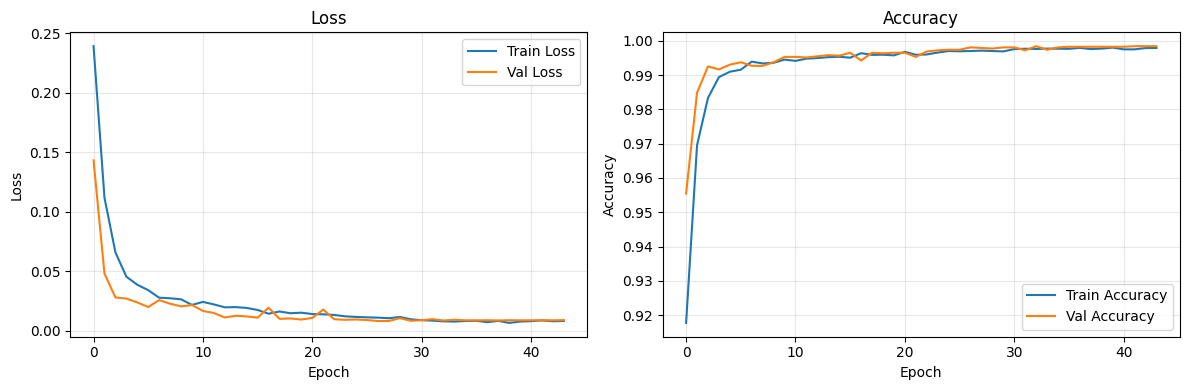

In [13]:
best_model = tf.keras.models.load_model('best_kws_model_v3.keras')
test_loss, test_acc, test_auc, precision, recall = best_model.evaluate(X_test, y_test, verbose=0)
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")


# Визуализация истории обучения

plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

### Подбор оптимального порога модели

In [6]:
import numpy as np
from sklearn import metrics
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns


def load_saved_dataset(filepath="kws_dataset_reduced_9.npz"):
    """
    Загрузка ранее сохранённого датасета.

    Аргументы:
    ----------
    filepath : str
        Путь к файлу с датасетом (npz-архив).

    Возвращает:
    -----------
    X_train, y_train, X_val, y_val, X_test, y_test : np.arrays
        Соответствующие выборки и метки.
    """
    data = np.load(filepath)
    X_train = data['X_train']
    y_train = data['y_train']
    X_val = data['X_val']
    y_val = data['y_val']
    X_test = data['X_test']
    y_test = data['y_test']
    print(f"Загружен датасет из {filepath}")
    print(f"X_train: shape {X_train.shape}")
    print(f"X_val: shape {X_val.shape}")
    print(f"X_test: shape {X_test.shape}")
    return X_train, y_train, X_val, y_val, X_test, y_test



def find_optimal_threshold(y_true, probabilities, method='balanced'):
    """
    Поиск оптимального порога для бинарной классификации.

    Аргументы:
    ----------
    y_true : array-like
        Истинные метки классов (1 - целевой класс, 0 - фоновый).
    probabilities : array-like
        Вероятности (score) принадлежности к целевому классу.
    method : str
        Метод оптимизации порога:
            - 'balanced'   : баланс между precision и recall
            - 'f1'         : максимизация F1-меры
            - 'cost'       : минимизация взвешенной стоимости ошибок
            - 'distance'   : минимизация расстояния до идеальной точки (1,1)
            - 'fn_fp'      : минимизация суммы FN + FP

    Возвращает:
    -----------
    best_threshold : float
        Найденный оптимальный порог.
    best_metrics : dict
        Метрики для лучшего порога.
    all_metrics : dict
        Метрики во всех расчетных точках порога.
    """
    
    thresholds = np.unique(np.sort(probabilities)) # Вычисление кандидатов на лучшие пороги
    thresholds = np.concatenate([[0.0], thresholds, [1.0]])  # Добавляем граничные значения
    
    best_threshold = 0.5
    best_score = -np.inf
    best_metrics = {}
    
    all_metrics = {
        'thresholds': [], 'f1': [], 'precision': [], 'recall': [],
        'accuracy': [], 'fp': [], 'fn': [], 'cost': []
    }  # Сохранение метрик для визуализации
    
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        
        all_metrics['thresholds'].append(threshold)
        all_metrics['f1'].append(f1)
        all_metrics['precision'].append(precision)
        all_metrics['recall'].append(recall)
        all_metrics['accuracy'].append(accuracy)
        all_metrics['fp'].append(fp)
        all_metrics['fn'].append(fn)        
        
        cost_fp = 1.0
        cost_fn = 1.0
        cost = fp * cost_fp + fn * cost_fn
        all_metrics['cost'].append(cost)  # Стоимость ошибок (по умолчанию равные)
        
        # Выбор критериев для оптимального порога
        if method == 'f1':
            score = f1
        elif method == 'balanced':            
            score = np.sqrt(precision * recall) if (precision > 0 and recall > 0) else 0.0  # Геометрическое среднее precision и recall
        elif method == 'cost':
            score = -cost
        elif method == 'distance':
            distance = np.sqrt((1 - precision)**2 + (1 - recall)**2)
            score = -distance
        elif method == 'fn_fp':
            score = -(fp + fn)  # Минимизируем сумму ошибок (FN + FP)
        else:
            score = f1
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
            best_metrics = {
                'threshold': threshold,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'fp': fp,
                'fn': fn,
                'tn': tn,
                'tp': tp,
                'cost': cost
            }
    
    return best_threshold, best_metrics, all_metrics


def find_optimal_threshold_custom_cost(y_true, probabilities, cost_fp=1.0, cost_fn=1.0):
    """
    Поиск оптимального порога с пользовательскими весами ошибок.

    Параметры:
    ----------
    y_true : array-like
        Истинные метки классов.
    probabilities : array-like
        Предсказанные вероятности.
    cost_fp : float
        "Штраф" за ложные срабатывания (FP).
    cost_fn : float
        "Штраф" за пропуски цели (FN).

    Возвращает:
    -----------
    best_threshold : float
        Лучший порог.
    best_cost : float
        Минимальная достигнутая стоимость ошибок.
    """
    thresholds = np.unique(np.sort(probabilities))
    thresholds = np.concatenate([[0.0], thresholds, [1.0]])

    best_threshold = 0.5
    best_cost = np.inf

    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel()
        total_cost = fp * cost_fp + fn * cost_fn
        if total_cost < best_cost:
            best_cost = total_cost
            best_threshold = threshold

    return best_threshold, best_cost


def plot_threshold_analysis(y_true, probabilities, all_metrics, best_threshold, best_metrics, method_name):
    """
    Визуализация зависимости различных метрик от порога.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    thresholds = all_metrics['thresholds']

    # График 1: Precision, Recall, F1, Accuracy
    axes[0].plot(thresholds, all_metrics['precision'], color='#0000e6', label='Precision', linewidth=2)
    axes[0].plot(thresholds, all_metrics['recall'], color='#800000', label='Recall', linewidth=2)
    axes[0].plot(thresholds, all_metrics['f1'], color='#1B998B', label='F1-score', linewidth=2)
    axes[0].plot(thresholds, all_metrics['accuracy'], color='#7200a3', label='Accuracy', linewidth=2)
    axes[0].axvline(best_threshold, color='purple', linestyle='--', linewidth=2,
                    label=f'Оптимальный порог = {best_threshold:.3f}')
    axes[0].set_xlabel('Порог')
    axes[0].set_ylabel('Значение')
    axes[0].set_title(f'Зависимость метрик от порога ({method_name})')
    axes[0].set_ylim(0.93, 1)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График 2: FP, FN, стоимость ошибок
    axes[1].plot(thresholds, all_metrics['fp'], color='#b00000', label='FP (ложные срабатывания)', linewidth=2)
    axes[1].plot(thresholds, all_metrics['fn'], color='#264653', label='FN (пропуски целей)', linewidth=2)
    axes[1].plot(thresholds, all_metrics['cost'], color='#F4A261', label='Общая стоимость (FP+FN)', linewidth=2, linestyle='--')
    axes[1].axvline(best_threshold, color='purple', linestyle='--', linewidth=2,
                    label=f'Оптимальный порог = {best_threshold:.3f}')
    axes[1].set_xlabel('Порог')
    axes[1].set_ylabel('Количество / Стоимость')
    axes[1].set_title('Зависимость ошибок и их стоимости от порога')
    axes[1].set_ylim(0, 175)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title="Матрица ошибок"):
    """
    Визуализация матрицы ошибок (confusion matrix).

    Параметры:
    ----------
    y_true : array-like
        Истинные значения классов.
    y_pred : array-like
        Предсказанные значения классов.
    title : str
        Заголовок графика.
    """
    cm = metrics.confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Другие', 'Вижу цель'],
        yticklabels=['Другие', 'Вижу цель']
    )
    plt.xlabel('Предсказано')
    plt.ylabel('Истинное значение')
    plt.title(title)
    plt.tight_layout()
    plt.show()


X_train, y_train, X_val, y_val, X_test, y_test = load_saved_dataset()  # Загрузка данных

print("\nЗагрузка бинарной модели...")
binary_model = load_model("best_kws_model_v3.keras")

X_test_positive = X_test[y_test[:, 1] == 1]
X_test_negative = X_test[y_test[:, 0] == 1]
X_test_all = np.concatenate([X_test_positive, X_test_negative])

y_true = np.concatenate([np.ones(len(X_test_positive)), np.zeros(len(X_test_negative))]) # Формируем метки (1 — целевой класс, 0 — фоновый)

print("\nПолучение предсказаний модели...")
probabilities = binary_model.predict(X_test_all, verbose=0)
if probabilities.shape[1] == 2:
    probabilities = probabilities[:, 1]
else:
    probabilities = probabilities.flatten()


Загружен датасет из kws_dataset_reduced_9.npz
X_train: shape (26831, 101, 9)
X_val: shape (5749, 101, 9)
X_test: shape (5750, 101, 9)

Загрузка бинарной модели...

Получение предсказаний модели...


#### Подбор оптимального порога (минимизация FN + FP)

Оптимальный порог:        0.5654
Accuracy:                 0.9983
Precision:                0.9976
Recall:                   0.9976
F1-score:                 0.9976
FP (ложные срабатывания): 5
FN (пропуски целей):      5


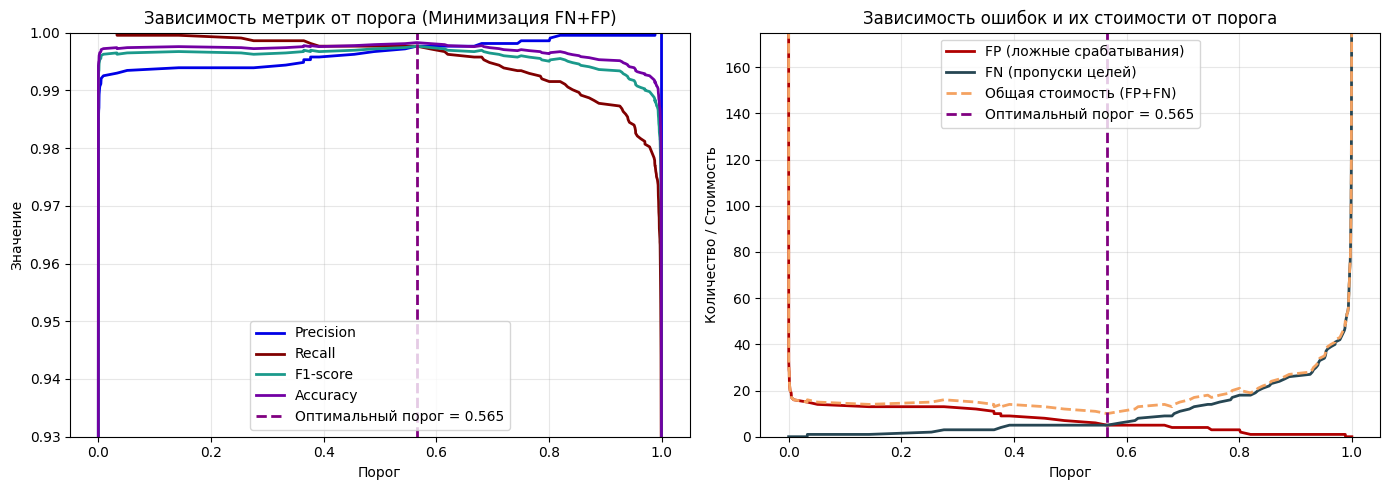

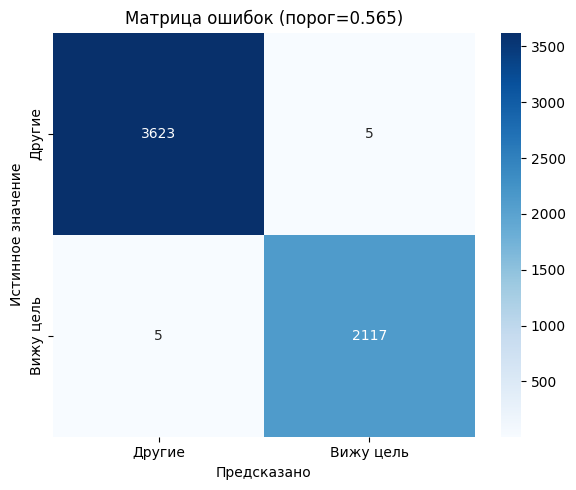

In [7]:
best_threshold, best_metrics, all_metrics = find_optimal_threshold(
    y_true, probabilities, method='fn_fp'
)

print(f"Оптимальный порог:        {best_threshold:.4f}")
print(f"Accuracy:                 {best_metrics['accuracy']:.4f}")
print(f"Precision:                {best_metrics['precision']:.4f}")
print(f"Recall:                   {best_metrics['recall']:.4f}")
print(f"F1-score:                 {best_metrics['f1']:.4f}")
print(f"FP (ложные срабатывания): {best_metrics['fp']}")
print(f"FN (пропуски целей):      {best_metrics['fn']}")


plot_threshold_analysis(
    y_true, probabilities, all_metrics,
    best_threshold, best_metrics,
    method_name='Минимизация FN+FP'
)


y_pred_optimal = (probabilities >= best_threshold).astype(int)
plot_confusion_matrix(
    y_true, y_pred_optimal, 
    title=f"Матрица ошибок (порог={best_threshold:.3f})"
)

#### Сравнение различных методов подбора порога

In [8]:
methods = ['f1', 'balanced', 'fn_fp', 'distance']
method_names = {
    'f1': 'Максимизация F1',
    'balanced': 'Баланс Precision/Recall',
    'fn_fp': 'Минимизация FN+FP',
    'distance': 'Минимизация расстояния до идеала'
}

results = []

for method in methods:
    threshold, metrics_dict, _ = find_optimal_threshold(y_true, probabilities, method=method)
    results.append({
        'method': method_names[method],
        'threshold': threshold,
        'f1': metrics_dict['f1'],
        'precision': metrics_dict['precision'],
        'recall': metrics_dict['recall'],
        'fp': metrics_dict['fp'],
        'fn': metrics_dict['fn']
    })

print(f"\n{'Метод':<35} {'Порог':<8} {'F1':<8} {'Prec':<8} {'Rec':<8} {'FP':<6} {'FN':<6}")
print("-"*80)
for r in results:
    print(f"{r['method']:<35} {r['threshold']:.4f}  {r['f1']:.4f}   {r['precision']:.4f}   {r['recall']:.4f}   {r['fp']:>4}   {r['fn']:>4}")


Метод                               Порог    F1       Prec     Rec      FP     FN    
--------------------------------------------------------------------------------
Максимизация F1                     0.5654  0.9976   0.9976   0.9976      5      5
Баланс Precision/Recall             0.5654  0.9976   0.9976   0.9976      5      5
Минимизация FN+FP                   0.5654  0.9976   0.9976   0.9976      5      5
Минимизация расстояния до идеала    0.5654  0.9976   0.9976   0.9976      5      5


#### Подбор порога с разными весами ошибок

In [9]:
cost_configs = [
    (1.0, 1.0, "FP = FN (одинаково)"),
    (4.0, 1.0, "FP дороже FN (строже к ложным срабатываниям)"),
    (1.0, 4.0, "FN дороже FP (важнее не пропустить цель)"),
]

print(f"\n{'Конфигурация':<35} {'Порог':<8} {'FP':<6} {'FN':<6} {'Стоимость':<10}")
print("-"*65)

for cost_fp, cost_fn, desc in cost_configs:
    threshold, total_cost = find_optimal_threshold_custom_cost(
        y_true, probabilities, cost_fp, cost_fn
    )
    y_pred = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel()
    print(f"{desc:<35} {threshold:.4f}  {fp:>4}   {fn:>4}   {total_cost:>8.1f}")


# Выбираем 'fn_fp' как наиболее сбалансированный метод
final_threshold, final_metrics, _ = find_optimal_threshold(y_true, probabilities, method='fn_fp')

print(f"\nРекомендуемый порог: {final_threshold:.4f}")
print("\nОжидаемое качество:")
print(f"  • Точность (Precision): {final_metrics['precision']:.4f} "
      f"({final_metrics['tp']} / {final_metrics['tp'] + final_metrics['fp']})")
print(f"  • Полнота (Recall):    {final_metrics['recall']:.4f} "
      f"({final_metrics['tp']} / {final_metrics['tp'] + final_metrics['fn']})")
print(f"  • F1-мера:             {final_metrics['f1']:.4f}")
print(f"\n  • Ложных срабатываний (FP): {final_metrics['fp']}")
print(f"  • Пропусков целей (FN):    {final_metrics['fn']}")

np.save("optimal_threshold.npy", final_threshold)  # Сохранение оптимального порога для воспроизведения
print(f"\nПорог сохранён в 'optimal_threshold.npy'")


Конфигурация                        Порог    FP     FN     Стоимость 
-----------------------------------------------------------------
FP = FN (одинаково)                 0.5654     5      5       10.0
FP дороже FN (строже к ложным срабатываниям) 0.8201     1     18       22.0
FN дороже FP (важнее не пропустить цель) 0.0329    15      0       15.0

Рекомендуемый порог: 0.5654

Ожидаемое качество:
  • Точность (Precision): 0.9976 (2117 / 2122)
  • Полнота (Recall):    0.9976 (2117 / 2122)
  • F1-мера:             0.9976

  • Ложных срабатываний (FP): 5
  • Пропусков целей (FN):    5

Порог сохранён в 'optimal_threshold.npy'
